### LINEAR MODEL PRACTICE

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [45]:
df = pd.read_csv("Salary_dataset.csv")

In [46]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [47]:
df.drop("Unnamed: 0", axis = 1 , inplace = True)

In [48]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


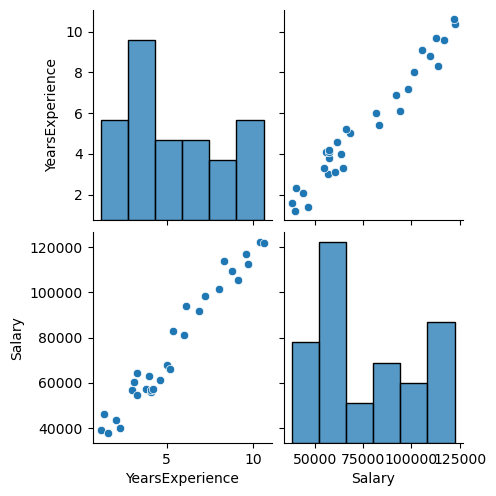

In [49]:
sns.pairplot(df)

In [50]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


<Axes: >

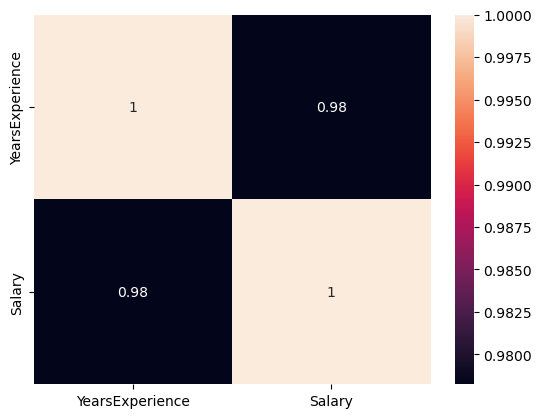

In [51]:
sns.heatmap(df.corr(), annot = True)

In [52]:
X = df[["YearsExperience"]]
y = df["Salary"]

In [53]:
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.5 , random_state=42)

In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [55]:
regression = LinearRegression(n_jobs=-1)
regression.fit(X_train_scaled, y_train)

LinearRegression(n_jobs=-1)

In [56]:
regression.coef_

array([26413.3539151])

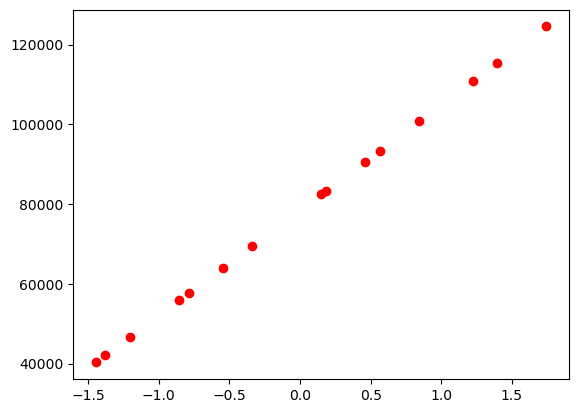

In [57]:
# plotting the best fit line 
plt.scatter(X_train_scaled , regression.predict(X_train_scaled), color = "red")

In [58]:
regression.intercept_

78495.93333333332

In [61]:
prediction = regression.predict(X_test_scaled)
y_pred_test = regression.intercept_ + regression.coef_ * X_test_scaled

### Performance metrics 

In [62]:
mse = mean_squared_error(y_test , prediction)
mae = mean_absolute_error(y_test , prediction)
rmse = np.sqrt(mse)
print("MSE : ", mse)
print("MAE : ", mae)
print("RMSE : ", rmse)

MSE :  43144969.58282781
MAE :  5693.2832101433
RMSE :  6568.4830503570465


In [64]:
# R2
score = r2_score(y_test , prediction)
print("R2 Score : ", score)
# adjusted r2 
score1 = 1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test_scaled.shape[1]-1)
print("Adjusted R2 Score : ", score1)

R2 Score :  0.9400870162554471
Adjusted R2 Score :  0.9354783251981738


### OLS prediction

In [67]:
import statsmodels.api as sm 
model = sm.OLS(y_train ,X_train_scaled).fit()
prediction1 = model.predict(X_test_scaled)
print(model.summary())


                                 OLS Regression Results                                
Dep. Variable:                 Salary   R-squared (uncentered):                   0.101
Model:                            OLS   Adj. R-squared (uncentered):              0.037
Method:                 Least Squares   F-statistic:                              1.579
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                       0.229
Time:                        14:27:35   Log-Likelihood:                         -190.37
No. Observations:                  15   AIC:                                      382.7
Df Residuals:                      14   BIC:                                      383.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\ASHVITA\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=15
  res = hypotest_fun_out(*samples, **kwds)


In [66]:
print(prediction1)

[ 37811.47245571  -5253.29019578  24983.67081484  -1588.20401268
 -20829.90647398 -16248.5487451   44225.37327614  29565.02854372
 -13499.73410777 -40071.60893529 -29992.62193175  -3420.74710423
 -23578.72111131 -12583.462562   -13499.73410777]


### New Data Prediction

In [71]:
New_value = float(input("Enter the years of experience to predict the salary : "))
regression.predict(scaler.transform([[New_value]]))

c:\Users\ASHVITA\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([58582.29840513])